
---

# ***`5 Key Points About Ridge Regression`***

---


### **1. How the Coefficents get affected?**

In [94]:
# Import libraries
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,Ridge
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from mlxtend.evaluate import bias_variance_decomp

In [64]:
# load the dataset
data = load_diabetes()

In [65]:
# convert the data into dataframe
df = pd.DataFrame(
    data.data,
    columns=data.feature_names
)
df['TARGET'] = data.target

In [66]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,TARGET
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [67]:
df.shape

(442, 11)

In [68]:
# train test split the data
X_train,X_test,y_train,y_test = train_test_split(
    data.data,data.target,
    test_size=0.2,
    random_state=2
)

In [69]:
# Initialize lists to store coefficients and R² scores
coefs = []
r2_scores = []

# Iterate over different regularization strengths for Ridge regression
for i in [0, 10, 100, 1000]:
    reg = Ridge(alpha=i)  # Create a Ridge regression model with the specified alpha
    reg.fit(X_train, y_train)  # Fit the model to the training data
    
    coefs.append(reg.coef_.tolist())  # Store the model coefficients
    y_pred = reg.predict(X_test)  # Predict the target values for the test set
    r2_scores.append(r2_score(y_test, y_pred))  # Calculate and store the R² score

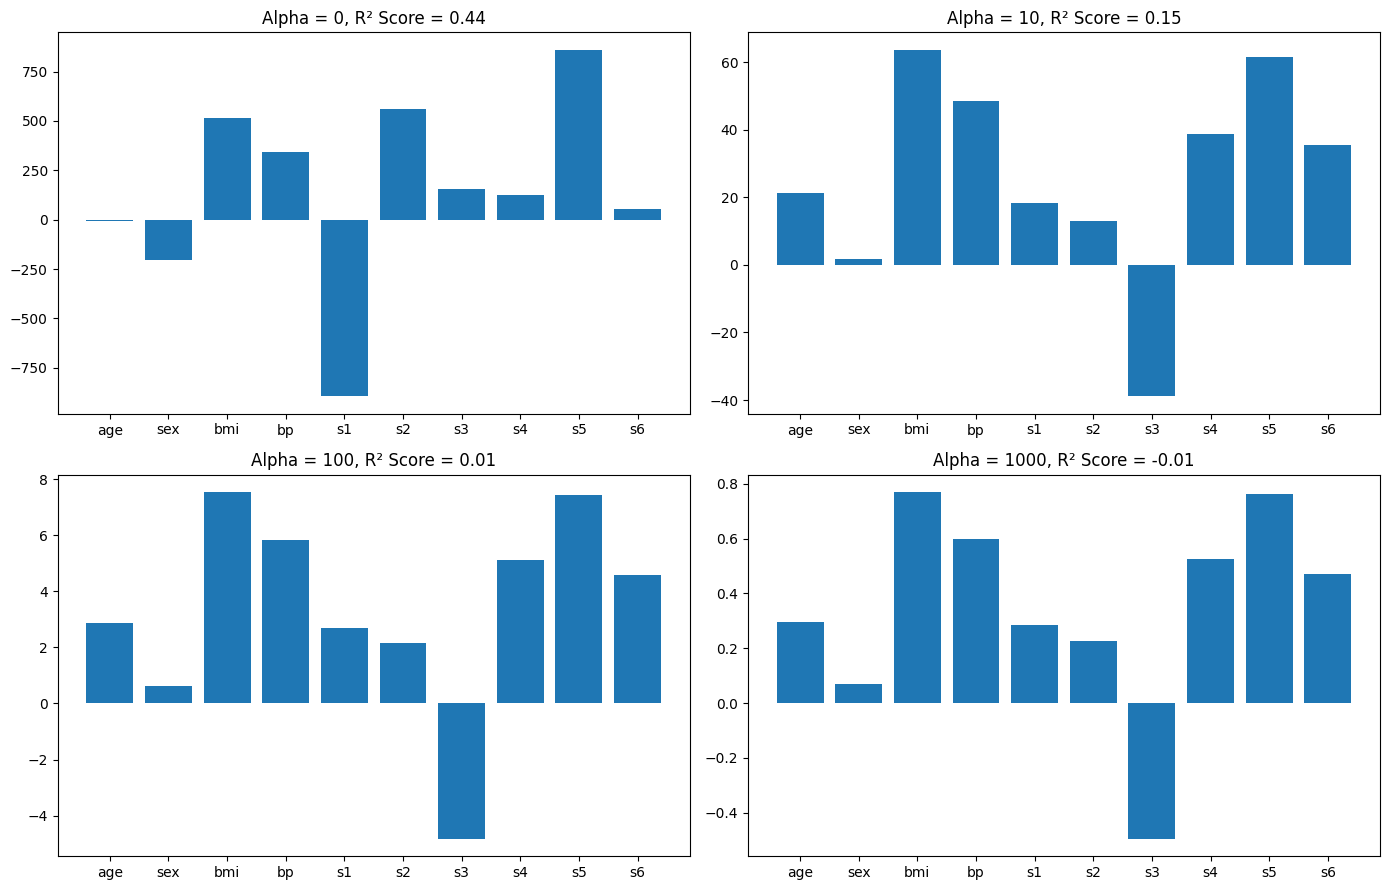

In [70]:
# Set up the figure size for the plots
plt.figure(figsize=(14, 9))

# Create a bar plot for each alpha value and corresponding R² score
plt.subplot(221)  # First subplot (top left)
plt.bar(data.feature_names, coefs[0])  # Bar plot for alpha = 0
plt.title('Alpha = 0, R² Score = {}'.format(round(r2_scores[0], 2)))  # Title with R² score

plt.subplot(222)  # Second subplot (top right)
plt.bar(data.feature_names, coefs[1])  # Bar plot for alpha = 10
plt.title('Alpha = 10, R² Score = {}'.format(round(r2_scores[1], 2)))  # Title with R² score

plt.subplot(223)  # Third subplot (bottom left)
plt.bar(data.feature_names, coefs[2])  # Bar plot for alpha = 100
plt.title('Alpha = 100, R² Score = {}'.format(round(r2_scores[2], 2)))  # Title with R² score

plt.subplot(224)  # Fourth subplot (bottom right)
plt.bar(data.feature_names, coefs[3])  # Bar plot for alpha = 1000
plt.title('Alpha = 1000, R² Score = {}'.format(round(r2_scores[3], 2)))  # Title with R² score

# Adjust layout for better spacing and display the plots
plt.tight_layout()
plt.show()  # Show all the plots

- Coefficents get shrink and close to zero everytime we increase value of lambda **$ \lambda $**.

### **2. Higher Values are Impacted More?**

In [71]:
# let's increase the values of coefficents
alphas = [0,0.0001,0.001,0.01,0.1,1,10,100,1000,10000]

coefs = []

for i in alphas:
    reg = Ridge(alpha=i)
    reg.fit(X_train,y_train)
    
    coefs.append(reg.coef_.tolist())

In [72]:
# convert the coefficents into array
input_array = np.array(coefs) 

In [73]:
# convert the input_array into dataframe
coef_df = pd.DataFrame(input_array,columns=data.feature_names)
coef_df['alpha'] = alphas
coef_df.set_index('alpha')

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
alpha,,,,,,,,,,
0.0000,-9.158653,-205.454322,516.693745,340.619999,-895.552002,561.220679,153.893110,126.731397,861.127002,52.421122
0.0001,-9.116119,-205.329219,516.889664,340.549436,-883.423872,551.559582,148.587063,125.353015,856.485935,52.468916
0.0010,-8.761487,-204.313404,518.380608,339.967926,-787.700510,475.282181,106.795253,114.629265,819.745723,52.873349
0.0100,-6.399507,-198.662945,522.056516,336.340595,-383.717571,152.670882,-66.053243,75.608209,659.875219,55.829221
0.1000,6.643733,-172.237474,485.529585,314.675846,-72.940209,-80.588688,-174.463527,83.614710,484.365316,73.585091
1.0000,42.242528,-57.304483,282.172125,198.059395,14.363734,-22.551079,-136.929684,102.023069,260.104294,98.552692
10.0000,21.174024,1.659837,63.659826,48.492858,18.421510,12.875466,-38.915435,38.842475,61.612302,35.505383
100.0000,2.858980,0.629453,7.540605,5.849949,2.710879,2.142135,-4.834047,5.108223,7.448451,4.576129
1000.0000,0.295726,0.069290,0.769004,0.597824,0.282900,0.225936,-0.495607,0.527031,0.761496,0.471029


In [74]:
# Define a list of alpha values for Ridge regression
alphas = [0, 0.0001, 0.0005, 0.001, 0.005, 0.1, 0.5, 1, 5, 10]

# Initialize a list to store the coefficients for each alpha
coefs = []

# Iterate over each alpha value to fit the Ridge regression model
for i in alphas:
    reg = Ridge(alpha=i)  # Create a Ridge regression model with the specified alpha
    reg.fit(X_train, y_train)  # Fit the model to the training data
    
    coefs.append(reg.coef_.tolist())  # Store the model coefficients as a list

In [75]:
# transpose the input_array for graph plotting 
input_array = np.array(coefs).T

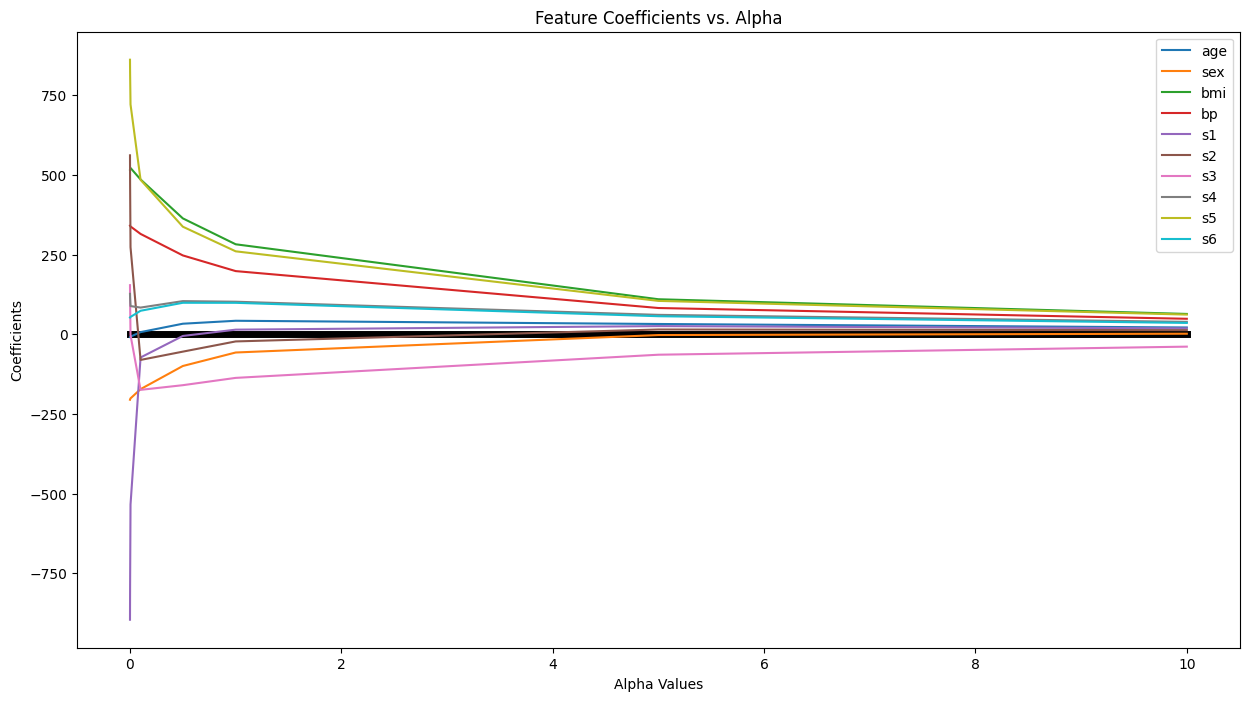

In [76]:
# Set up the figure size for the plot
plt.figure(figsize=(15, 8))

# Plot a horizontal line at y=0 for reference
plt.plot(alphas, np.zeros(len(alphas)), color='black', linewidth=5)

# Plot each feature's coefficients against the alpha values
for i in range(input_array.shape[0]):
    plt.plot(alphas, input_array[i], label=data.feature_names[i])  # Plot each feature's coefficients

# Add a legend to identify each feature's line
plt.legend()

# Optional: Add titles and labels for clarity
plt.title('Feature Coefficients vs. Alpha')
plt.xlabel('Alpha Values')
plt.ylabel('Coefficients')
plt.show()

- Higher Values of alpha converge close to zero not exactly zero. 

### **3. Impact on Bias Variance TradeOff**

In [77]:
# load the diabetes dataset again 
data=load_diabetes()
print(data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [78]:
# split the data into dependent and independent variables
X=data.data
y=data.target

In [79]:
# train test split the data
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=45,
)

In [80]:
# initialize linear regression model
L=LinearRegression()

# fit the model into train and test data
L.fit(X_train,y_train)

# check the coefficents and intercepts
print(L.coef_)
print(L.intercept_)

[  23.45465406 -247.42747406  492.1087518   329.35876431 -970.79723039
  573.54295519  182.42162368  255.92168168  794.21609282   89.32249214]
152.13623331746496


In [81]:
y_pred=L.predict(X_test)

In [82]:
# evaluate the regression model
print("R2 score",r2_score(y_test,y_pred))
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred)))

R2 score 0.5188113124539249
RMSE 48.72713760953253


In [83]:
R=Ridge(alpha=100000)

In [84]:
R.fit(X_train,y_train)

Ridge(alpha=100000)

In [85]:
print(R.coef_)
print(R.intercept_)

[ 0.00260126  0.00057066  0.00776597  0.0060976   0.00233864  0.00184724
 -0.00513942  0.0052716   0.00734598  0.00528629]
151.83287930791352


In [86]:
y_pred1=R.predict(X_test)

In [87]:
print("R2 score",r2_score(y_test,y_pred1))
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred1)))

R2 score -0.00042490200441935855
RMSE 70.25956272917782


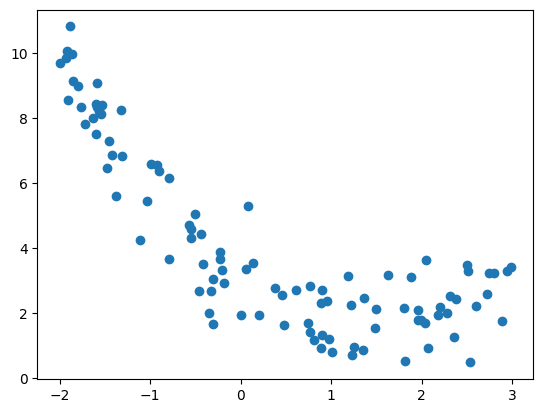

In [88]:
# Set the number of data points
m = 100

# Generate random x1 values in the range [-2, 3]
x1 = 5 * np.random.rand(m, 1) - 2

# Generate corresponding x2 values with a quadratic relationship and added noise
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m, 1)

# Create a scatter plot of the generated data
plt.scatter(x1, x2)

# Display the scatter plot
plt.show()

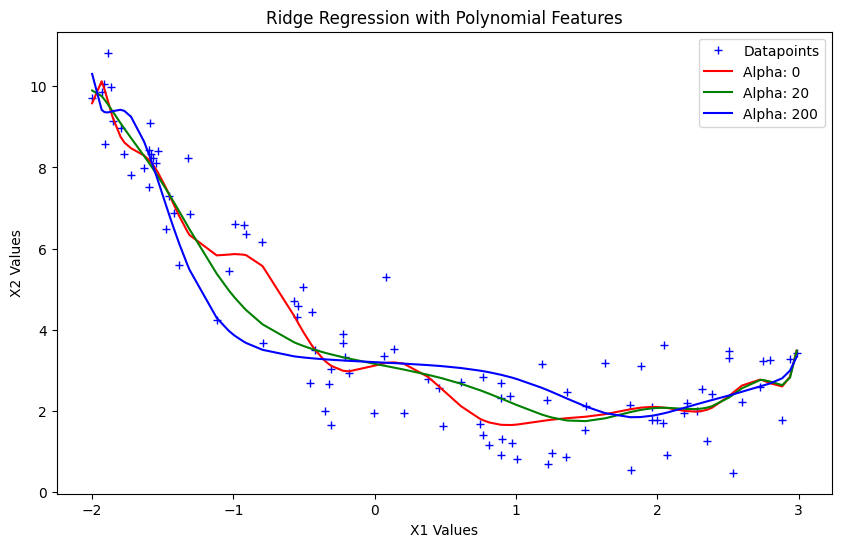

In [89]:
# Function to fit a Ridge regression model with polynomial features and return predictions
def get_preds_ridge(x1, x2, alpha):
    # Create a pipeline with polynomial feature transformation and Ridge regression
    model = Pipeline([
        ('poly_feats', PolynomialFeatures(degree=16)),  # Add polynomial features of degree 16
        ('ridge', Ridge(alpha=alpha))  # Ridge regression with specified alpha
    ])
    
    # Fit the model to the data
    model.fit(x1, x2)
    
    # Return predictions for the input data
    return model.predict(x1)

# List of alpha values for Ridge regression
alphas = [0, 20, 200]

# Corresponding colors for plotting
cs = ['r', 'g', 'b']

# Set up the figure size for the plot
plt.figure(figsize=(10, 6))

# Plot the original data points
plt.plot(x1, x2, 'b+', label='Datapoints')

# Iterate over each alpha and corresponding color for plotting predictions
for alpha, c in zip(alphas, cs):
    preds = get_preds_ridge(x1, x2, alpha)  # Get predictions from the Ridge model
    # Plot the predictions, sorted by x1 values for a smooth curve
    plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:, 0])], c, label='Alpha: {}'.format(alpha))

# Add a title and axis labels
plt.title('Ridge Regression with Polynomial Features')
plt.xlabel('X1 Values')
plt.ylabel('X2 Values')

# Add a legend to the plot
plt.legend()

# Display the plot
plt.show()

- Graph clearly shows the case of underfitting. 

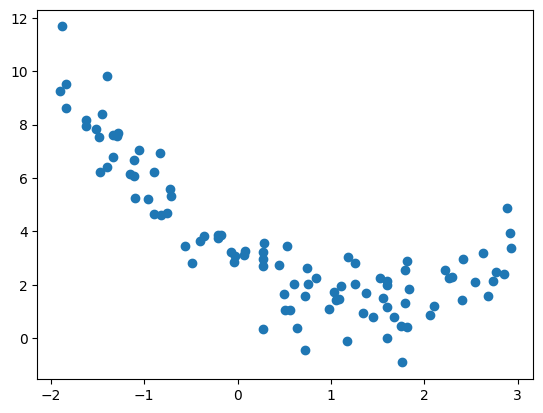

In [91]:
# Set the number of data points
m = 100

# Generate random X values in the range [-2, 3]
X = 5 * np.random.rand(m, 1) - 2

# Generate corresponding X values with a quadratic relationship and added noise
y = 0.7 * X ** 2 - 2 * X + 3 + np.random.randn(m, 1)

# Create a scatter plot of the generated data
plt.scatter(X, y)

# Display the scatter plot
plt.show()

In [92]:
# train test split the data
X_train,X_test,y_train,y_test = train_test_split(
    X.reshape(100,1),
    y.reshape(100),
    test_size=0.2,
    random_state=2,
)

In [93]:
# Create a PolynomialFeatures object with the desired degree
poly = PolynomialFeatures(degree=15)

# Transform the training data to include polynomial features
X_train = poly.fit_transform(X_train)

# Transform the test data using the same polynomial feature transformation
X_test = poly.transform(X_test)

- This will calculate bias and variance for a particular Lambda value

In [95]:
# Generate a range of alpha values for Ridge regression
alphas = np.linspace(0, 30, 100)

# Initialize lists to store the results
loss = []
bias = []
variance = []

# Iterate over each alpha value to compute bias-variance decomposition
for i in alphas:
    reg = Ridge(alpha=i)  # Create a Ridge regression model with the current alpha
    avg_expected_loss, avg_bias, avg_var = bias_variance_decomp(
        reg, X_train, y_train, X_test, y_test, 
        loss='mse',  # Specify the loss function as mean squared error
        random_seed=123  # Set a random seed for reproducibility
    )
    
    # Append results to corresponding lists
    loss.append(avg_expected_loss)
    bias.append(avg_bias)
    variance.append(avg_var)

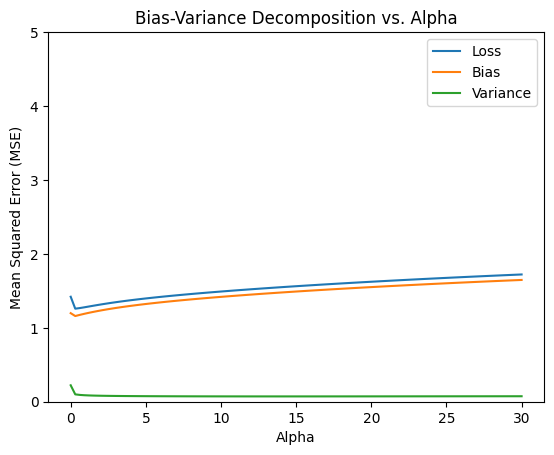

In [96]:
# Plot the loss, bias, and variance against alpha values
plt.plot(alphas, loss, label='Loss')        # Plot loss
plt.plot(alphas, bias, label='Bias')        # Plot bias
plt.plot(alphas, variance, label='Variance')  # Plot variance

# Set the y-axis limit for better visualization
plt.ylim(0, 5)

# Label the x-axis and y-axis
plt.xlabel('Alpha')
plt.ylabel('Mean Squared Error (MSE)')

# Add a title to the plot
plt.title('Bias-Variance Decomposition vs. Alpha')

# Add a legend to distinguish the lines
plt.legend()

# Display the plot
plt.show()

### **4. Effect of Regularization on the Loss Function**

[27.82809103]
-2.29474455867698


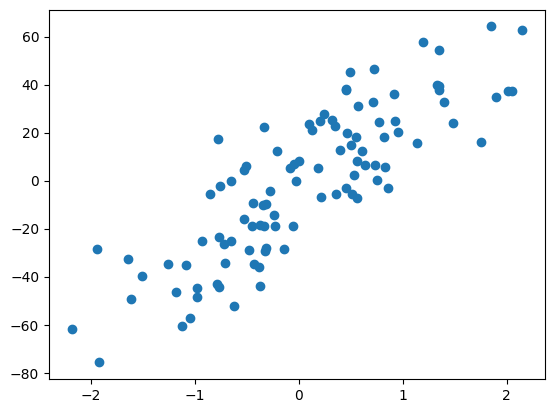

In [97]:
# make a sample dataset
from sklearn.datasets import make_regression

X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)

plt.scatter(X,y)

from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(X,y)
print(reg.coef_)
print(reg.intercept_)

In [98]:
def cal_loss(m,alpha):
    return np.sum((y - m*X.ravel() + 2.29)**2) + alpha*m*m

In [99]:
def predict(m):
    return m*X - 2.29

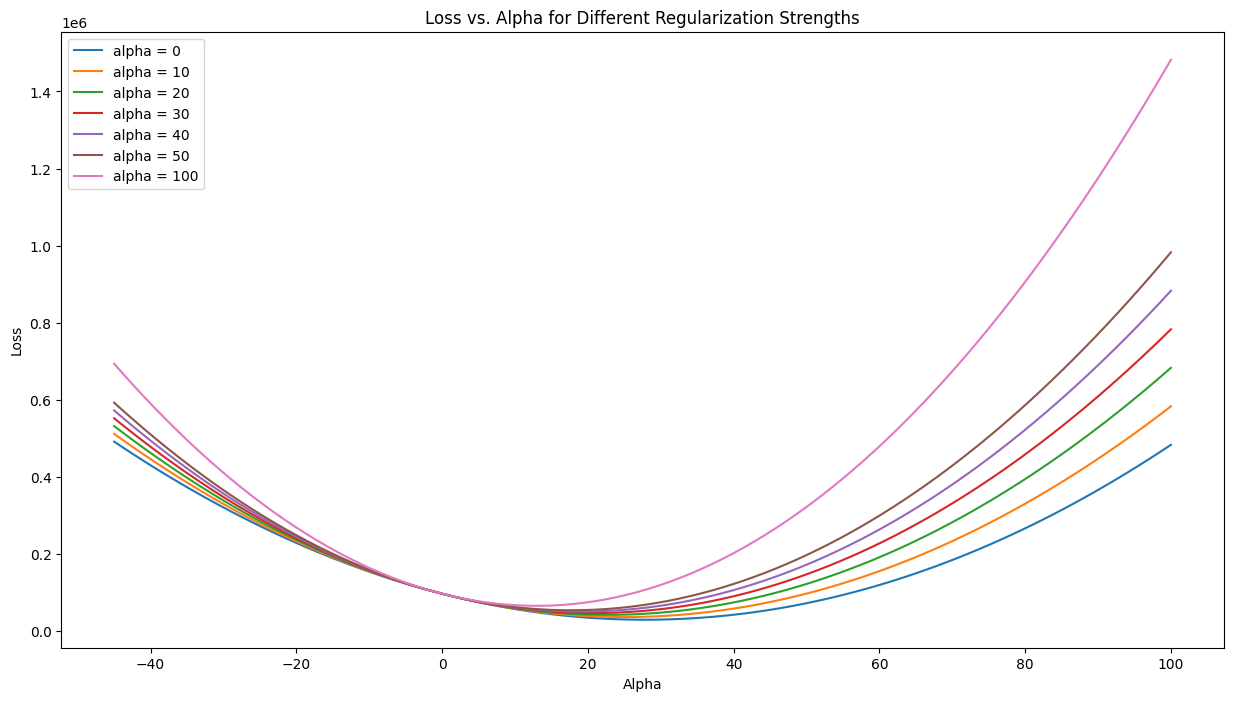

In [101]:
# Generate a range of alpha values from -45 to 100
m = np.linspace(-45, 100, 100)
plt.figure(figsize=(15, 8))
# Iterate over specified alpha values
for j in [0, 10, 20, 30, 40, 50, 100]:
    loss = []  # Initialize a list to store loss values for the current alpha
    # Calculate loss for each value in the m array
    for i in range(m.shape[0]):
        loss_i = cal_loss(m[i], j)  # Calculate the loss using the custom function cal_loss
        loss.append(loss_i)  # Append the calculated loss to the list
    # Plot the loss against the alpha values for the current j
    plt.plot(m, loss, label='alpha = {}'.format(j))

# Add a legend to distinguish the lines
plt.legend()

# Label the x-axis and y-axis
plt.xlabel('Alpha')
plt.ylabel('Loss')

# Add a title to the plot
plt.title('Loss vs. Alpha for Different Regularization Strengths')

# Display the plot
plt.show()

---